<a href="https://colab.research.google.com/github/Arigalan/An-lisis-de-empresa-de-retail/blob/main/Proyecto_DA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importamos la librería de pandas para poder hacer el análisis

In [1]:
import pandas as pd

Creamos los DataFrames con los archivos subidos

In [2]:
customers = pd.read_excel("CustomersData.xlsx")
discount = pd.read_csv("Discount_Coupon.csv")
marketing = pd.read_csv("Marketing_Spend.csv")
sales = pd.read_csv("Online_Sales.csv")
tax = pd.read_excel("Tax_amount.xlsx")

Mostramos las tablas ya importadas para verificar que no existen errores

In [3]:
customers

,CustomerID,Gender,Location,Tenure_Months
0,17850,M,Chicago,12
1,13047,M,California,43
2,12583,M,Chicago,33
3,13748,F,California,30
4,15100,M,California,49
...,...,...,...,...
1463,14438,F,New York,41
1464,12956,F,Chicago,48
1465,15781,M,New Jersey,19
1466,14410,F,New York,45


In [4]:
discount

,Month,Product_Category,Coupon_Code,Discount_pct
0,Jan,Apparel,SALE10,10
1,Feb,Apparel,SALE20,20
2,Mar,Apparel,SALE30,30
3,Jan,Nest-USA,ELEC10,10
4,Feb,Nest-USA,ELEC20,20
...,...,...,...,...
199,Nov,Notebooks & Journals,NJ20,20
200,Dec,Notebooks & Journals,NJ30,30
201,Oct,Android,AND10,10
202,Nov,Android,AND20,20


In [5]:
marketing

,Date,Offline_Spend,Online_Spend
0,1/1/2019,4500,2424.50
1,1/2/2019,4500,3480.36
2,1/3/2019,4500,1576.38
3,1/4/2019,4500,2928.55
4,1/5/2019,4500,4055.30
...,...,...,...
360,12/27/2019,4000,3396.87
361,12/28/2019,4000,3246.84
362,12/29/2019,4000,2546.58
363,12/30/2019,4000,674.31


In [6]:
sales

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status
0,17850,16679,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used
1,17850,16680,1/1/2019,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,1,153.71,6.50,Used
2,17850,16681,1/1/2019,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,1,2.05,6.50,Used
3,17850,16682,1/1/2019,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used
4,17850,16682,1/1/2019,GGOEGBJL013999,Google Canvas Tote Natural/Navy,Bags,1,16.50,6.50,Used
...,...,...,...,...,...,...,...,...,...,...
52919,14410,48493,12/31/2019,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,1,121.30,6.50,Clicked
52920,14410,48494,12/31/2019,GGOEGAEB091117,Google Zip Hoodie Black,Apparel,1,48.92,6.50,Used
52921,14410,48495,12/31/2019,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,1,151.88,6.50,Used
52922,14600,48496,12/31/2019,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,6.50,Clicked


In [7]:
tax

,Product_Category,GST
0,Nest-USA,0.10
1,Office,0.10
2,Apparel,0.18
3,Bags,0.18
4,Drinkware,0.18
5,Lifestyle,0.18
6,Notebooks & Journals,0.05
7,Headgear,0.05
8,Waze,0.18
9,Fun,0.18


Mostramos cuales columnas tiene cada tabla

In [8]:
customers.columns

Index(['CustomerID', 'Gender', 'Location', 'Tenure_Months'], dtype='object')

In [9]:
discount.columns

Index(['Month', 'Product_Category', 'Coupon_Code', 'Discount_pct'], dtype='object')

In [10]:
marketing.columns

Index(['Date', 'Offline_Spend', 'Online_Spend'], dtype='object')

In [11]:
sales.columns

Index(['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status'],
      dtype='object')

In [12]:
tax.columns

Index(['Product_Category', 'GST'], dtype='object')

Vemos cuales son los tipos de producto y los tipos de cupones

In [13]:
sales['Product_Category'].unique()

array(['Nest-USA', 'Office', 'Apparel', 'Bags', 'Drinkware', 'Lifestyle',
       'Notebooks & Journals', 'Headgear', 'Waze', 'Fun', 'Nest-Canada',
       'Backpacks', 'Google', 'Bottles', 'Gift Cards', 'More Bags',
       'Housewares', 'Android', 'Accessories', 'Nest'], dtype=object)

In [14]:
sales['Coupon_Status'].unique()

array(['Used', 'Not Used', 'Clicked'], dtype=object)

De primer hallazgo, podríamos obtener el gasto total por categoría de producto. Para ésto, debemos de sumar la columna de "Avg_Price" con "Delivery_Charges" y, para las órdenes que hayan utilizado un cupón, restarle el valor del cupón.

Para saber el valor del cupón, debemos de utilizar la tabla "discount" y unirla con la tabla "sales".

 Primero, unimos la tabla sales con discount a través de "Product_Category" utilizando un left join para conservar todos los datos de sales, sin embargo, extraemos los meses de la tabla sales para poder hacer una llave compuesta entre Product_Category y Month, para eliminar los datos duplicados en caso de que hagamos un merge con una sóla llave primaria.

In [15]:
sales['Transaction_Date'] = pd.to_datetime(sales['Transaction_Date'])
sales['Month'] = sales['Transaction_Date'].dt.strftime('%b')  # Jan, Feb, Mar...

print("Meses en sales:", sorted(sales['Month'].unique()))
print("Meses en discount:", sorted(discount['Month'].unique()))

filas_antes = len(sales)

sales_discount = pd.merge(
    sales,
    discount,
    on=["Product_Category", "Month"],
    how="left"
)

# Rellenamos esos NaN con 0 (sin descuento aplicado)
sales_discount['Discount_pct'] = sales_discount['Discount_pct'].fillna(0)

Meses en sales: ['Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'May', 'Nov', 'Oct', 'Sep']
Meses en discount: ['Apr', 'Aug', 'Dec', 'Feb', 'Jan', 'Jul', 'Jun', 'Mar', 'May', 'Nov', 'Oct', 'Sep']


Vemos las columnas del join

In [16]:
sales_discount.columns

Index(['CustomerID', 'Transaction_ID', 'Transaction_Date', 'Product_SKU',
       'Product_Description', 'Product_Category', 'Quantity', 'Avg_Price',
       'Delivery_Charges', 'Coupon_Status', 'Month', 'Coupon_Code',
       'Discount_pct'],
      dtype='object')

Vemos como se comportan los datos en el estatus "Not Used" de los cupones

In [17]:
sales_discount[sales_discount['Coupon_Status'] == "Not Used"]

,CustomerID,Transaction_ID,Transaction_Date,Product_SKU,Product_Description,Product_Category,Quantity,Avg_Price,Delivery_Charges,Coupon_Status,Month,Coupon_Code,Discount_pct
3,17850,16682,2019-01-01,GGOEGAAB010516,Google Men's 100% Cotton Short Sleeve Hero Tee...,Apparel,5,17.53,6.50,Not Used,Jan,SALE10,10.0
6,17850,16682,2019-01-01,GGOEGDHC018299,Google 22 oz Water Bottle,Drinkware,15,3.08,6.50,Not Used,Jan,EXTRA10,10.0
17,13047,16685,2019-01-01,GGOEGDWR015799,Red Shine 15 oz Mug,Drinkware,1,10.72,6.50,Not Used,Jan,EXTRA10,10.0
20,13047,16687,2019-01-01,GGOEGOAQ012899,Ballpoint LED Light Pen,Office,1,2.58,6.50,Not Used,Jan,OFF10,10.0
30,12583,16692,2019-01-01,GGOEYOCR078099,YouTube Spiral Journal with Pen,Notebooks & Journals,26,7.93,102.79,Not Used,Jan,NJ10,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52888,14606,48467,2019-12-31,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,5,80.52,12.99,Not Used,Dec,ELEC30,30.0
52895,12956,48474,2019-12-31,GGOENEBQ086799,Nest Thermostat E - USA,Nest,1,100.91,19.99,Not Used,Dec,NE30,30.0
52896,12956,48475,2019-12-31,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,3,121.30,6.50,Not Used,Dec,ELEC30,30.0
52901,12956,48477,2019-12-31,GGOENEBQ086799,Nest Thermostat E - USA,Nest,1,100.91,6.50,Not Used,Dec,NE30,30.0


Creamos un nuevo DataFrame que nos de solamente las columnas importantes con las cuales queremos trabajar

In [18]:
df_gasto_total = sales_discount[['CustomerID', 'Quantity', 'Product_Category', 'Avg_Price', 'Delivery_Charges', 'Coupon_Status', 'Discount_pct']].copy()
df_gasto_total

,CustomerID,Quantity,Product_Category,Avg_Price,Delivery_Charges,Coupon_Status,Discount_pct
0,17850,1,Nest-USA,153.71,6.50,Used,10.0
1,17850,1,Nest-USA,153.71,6.50,Used,10.0
2,17850,1,Office,2.05,6.50,Used,10.0
3,17850,5,Apparel,17.53,6.50,Not Used,10.0
4,17850,1,Bags,16.50,6.50,Used,10.0
...,...,...,...,...,...,...,...
52919,14410,1,Nest-USA,121.30,6.50,Clicked,30.0
52920,14410,1,Apparel,48.92,6.50,Used,30.0
52921,14410,1,Nest-USA,151.88,6.50,Used,30.0
52922,14600,5,Nest-USA,80.52,6.50,Clicked,30.0


Importamos Numpy para hacer un tipo ciclo if que nos ayude a hacer las operaciones dependiendo de si el cupón se aplicó o no.

In [19]:
import numpy as np

df_gasto_total['Gasto_Total'] = np.where(
    df_gasto_total['Coupon_Status'] == "Not Used",
    df_gasto_total['Avg_Price'] * df_gasto_total['Quantity'] + df_gasto_total['Delivery_Charges'],
    (df_gasto_total['Avg_Price'] * df_gasto_total['Quantity'] + df_gasto_total['Delivery_Charges']) - (df_gasto_total['Avg_Price'] * df_gasto_total['Quantity'] * df_gasto_total['Discount_pct'] / 100)
)

Mostramos el df con la nueva columna agregada

In [20]:
df_gasto_total

,CustomerID,Quantity,Product_Category,Avg_Price,Delivery_Charges,Coupon_Status,Discount_pct,Gasto_Total
0,17850,1,Nest-USA,153.71,6.50,Used,10.0,144.839
1,17850,1,Nest-USA,153.71,6.50,Used,10.0,144.839
2,17850,1,Office,2.05,6.50,Used,10.0,8.345
3,17850,5,Apparel,17.53,6.50,Not Used,10.0,94.150
4,17850,1,Bags,16.50,6.50,Used,10.0,21.350
...,...,...,...,...,...,...,...,...
52919,14410,1,Nest-USA,121.30,6.50,Clicked,30.0,91.410
52920,14410,1,Apparel,48.92,6.50,Used,30.0,40.744
52921,14410,1,Nest-USA,151.88,6.50,Used,30.0,112.816
52922,14600,5,Nest-USA,80.52,6.50,Clicked,30.0,288.320


In [21]:
df_gasto_total['Product_Category'].unique()

array(['Nest-USA', 'Office', 'Apparel', 'Bags', 'Drinkware', 'Lifestyle',
       'Notebooks & Journals', 'Headgear', 'Waze', 'Fun', 'Nest-Canada',
       'Backpacks', 'Google', 'Bottles', 'Gift Cards', 'More Bags',
       'Housewares', 'Android', 'Accessories', 'Nest'], dtype=object)

Utilizamos la función describe() para poder ver cual fue la órden más barata hasta la más cara y el promedio de ticket de compra.

In [22]:
df_gasto_total.describe()

,CustomerID,Quantity,Avg_Price,Delivery_Charges,Discount_pct,Gasto_Total
count,52924.00000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000
mean,15346.70981,4.497638,52.237646,10.517630,19.802358,84.055316
std,1766.55602,20.104711,64.006882,19.475613,8.278878,144.500418
min,12346.00000,1.000000,0.390000,0.000000,0.000000,3.708000
25%,13869.00000,1.000000,5.700000,6.000000,10.000000,17.094000
50%,15311.00000,1.000000,16.990000,6.000000,20.000000,37.261000
75%,16996.25000,2.000000,102.130000,6.500000,30.000000,113.100000
max,18283.00000,900.000000,355.740000,521.360000,30.000000,8552.000000


Ahora, para calcular la suma de impuestos a pagar, debemos de hacer un merge entre gasto_total y Tax a través de Product_Category para calcular el impuesto sobre el subtotal de la compra, y así poder calcular el total real de la compra con impuestos.

In [23]:
total_tax = pd.merge(
    df_gasto_total,
    tax,
    on="Product_Category",
    how="left"
)
total_tax

,CustomerID,Quantity,Product_Category,Avg_Price,Delivery_Charges,Coupon_Status,Discount_pct,Gasto_Total,GST
0,17850,1,Nest-USA,153.71,6.50,Used,10.0,144.839,0.10
1,17850,1,Nest-USA,153.71,6.50,Used,10.0,144.839,0.10
2,17850,1,Office,2.05,6.50,Used,10.0,8.345,0.10
3,17850,5,Apparel,17.53,6.50,Not Used,10.0,94.150,0.18
4,17850,1,Bags,16.50,6.50,Used,10.0,21.350,0.18
...,...,...,...,...,...,...,...,...,...
52919,14410,1,Nest-USA,121.30,6.50,Clicked,30.0,91.410,0.10
52920,14410,1,Apparel,48.92,6.50,Used,30.0,40.744,0.18
52921,14410,1,Nest-USA,151.88,6.50,Used,30.0,112.816,0.10
52922,14600,5,Nest-USA,80.52,6.50,Clicked,30.0,288.320,0.10


In [24]:
total_tax['Total_Con_Impuestos'] = total_tax['Gasto_Total'] + (total_tax['Gasto_Total'] * total_tax['GST'])
total_tax

,CustomerID,Quantity,Product_Category,Avg_Price,Delivery_Charges,Coupon_Status,Discount_pct,Gasto_Total,GST,Total_Con_Impuestos
0,17850,1,Nest-USA,153.71,6.50,Used,10.0,144.839,0.10,159.32290
1,17850,1,Nest-USA,153.71,6.50,Used,10.0,144.839,0.10,159.32290
2,17850,1,Office,2.05,6.50,Used,10.0,8.345,0.10,9.17950
3,17850,5,Apparel,17.53,6.50,Not Used,10.0,94.150,0.18,111.09700
4,17850,1,Bags,16.50,6.50,Used,10.0,21.350,0.18,25.19300
...,...,...,...,...,...,...,...,...,...,...
52919,14410,1,Nest-USA,121.30,6.50,Clicked,30.0,91.410,0.10,100.55100
52920,14410,1,Apparel,48.92,6.50,Used,30.0,40.744,0.18,48.07792
52921,14410,1,Nest-USA,151.88,6.50,Used,30.0,112.816,0.10,124.09760
52922,14600,5,Nest-USA,80.52,6.50,Clicked,30.0,288.320,0.10,317.15200


Declaramos una columna para el total con impuestos

Ahora, una vez que obtuvimos el gasto total por categoría de producto, podemos hacer un gráfico de barras para hacer la comparación entre el promedio de esos gastos por categoría.

In [25]:
import matplotlib.pyplot as plt

In [26]:
df_avg_gasto_total = total_tax.groupby('Product_Category')['Total_Con_Impuestos'].mean().reset_index()
df_avg_gasto_total

,Product_Category,Total_Con_Impuestos
0,Accessories,42.009400
1,Android,24.532993
2,Apparel,43.579522
3,Backpacks,122.799674
4,Bags,95.402924
5,Bottles,36.283921
6,Drinkware,74.127582
7,Fun,58.331235
8,Gift Cards,113.540092
9,Google,128.089867


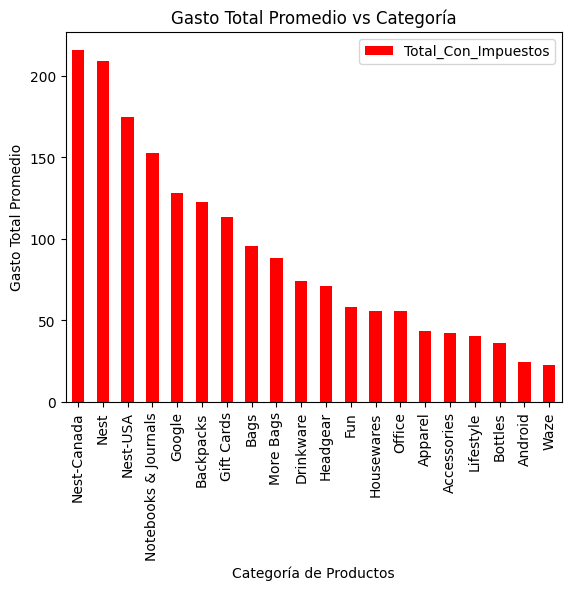

In [27]:
df_avg_gasto_total = df_avg_gasto_total.sort_values(by='Total_Con_Impuestos', ascending=False)

df_avg_gasto_total.plot(kind='bar', x='Product_Category', y='Total_Con_Impuestos', color='red')
plt.xlabel('Categoría de Productos')
plt.ylabel('Gasto Total Promedio')
plt.title('Gasto Total Promedio vs Categoría')
plt.show()

Con este hallazgo, podemos ver de que la categoría en la que los usuarios gastan más dinero en sus compras es en la de Nest-Canada.

Pero para estar seguros de que queremos que las gráficas no estén afectadas por outliers, hagamos la detección de outliers y, si es que hay, modificar el dataframe.

In [28]:
Q1 = total_tax['Total_Con_Impuestos'].quantile(0.25)
Q2 = total_tax['Total_Con_Impuestos'].quantile(0.50)
Q3 = total_tax['Total_Con_Impuestos'].quantile(0.75)
IQR = Q3 - Q1

In [29]:
lim_inferior = Q1 - 1.5 * IQR
lim_superior = Q3 + 1.5 * IQR
print(lim_inferior, lim_superior)

-136.84259999999998 281.16156


In [30]:
df_sin_outliers = total_tax[(total_tax['Total_Con_Impuestos'] >= lim_inferior) & (total_tax['Total_Con_Impuestos'] <= lim_superior)]

In [31]:
df_sin_outliers2 = df_sin_outliers.groupby('Product_Category')['Total_Con_Impuestos'].mean().reset_index()

Volvemos a hacer la gráfica ahora sin valores outliers que puedan afectar nuestro modelo.

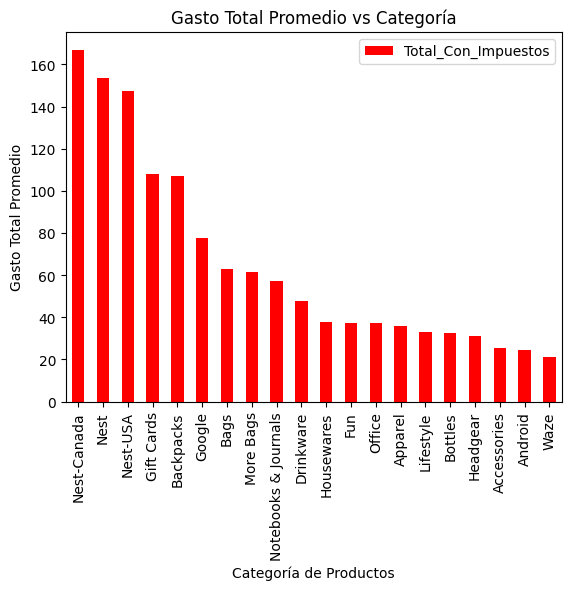

In [32]:
df_sin_outliers2 = df_sin_outliers2.sort_values(by='Total_Con_Impuestos', ascending=False)

df_sin_outliers2.plot(kind='bar', x='Product_Category', y='Total_Con_Impuestos', color='red')
plt.xlabel('Categoría de Productos')
plt.ylabel('Gasto Total Promedio')
plt.title('Gasto Total Promedio vs Categoría')
plt.show()

Ahora, con esta nueva gráfica podemos ver varios cambios, pero entre los más importantes es que redujeron la cantidad de datos graficados. Por lo cual, esto quiere decir que:

1. Los outliers si afectaron el análisis de nuestros datos.

2. Dado que la categoría 'Nest-Canada' es la que más gasto total tiene, debemos de optimizar más el inventario en ésta categoría de productos.

### Análisis de la categoría 'Waze'

Vamos a empezar analizando las métricas clave para la categoría 'Waze' y compararlas con el promedio general para ver dónde se encuentran las diferencias.

In [33]:
# Filtrar el DataFrame para la categoría 'Housewares' (usando el DataFrame sin outliers)
df_waze = df_sin_outliers[df_sin_outliers['Product_Category'] == 'Waze']
df_nest_canada = df_sin_outliers[df_sin_outliers['Product_Category'] == 'Nest-Canada']

print("\nEstadísticas generales (sin outliers) para comparación:")
display(df_waze[['Avg_Price', 'Delivery_Charges', 'Discount_pct', 'Gasto_Total']].describe())

print("\nEstadísticas de la categoría 'Nest-Canada' (sin outliers):")
display(df_nest_canada[['Avg_Price', 'Delivery_Charges', 'Discount_pct', 'Gasto_Total']].describe())


Estadísticas generales (sin outliers) para comparación:


,Avg_Price,Delivery_Charges,Discount_pct,Gasto_Total
count,552.000000,552.000000,552.000000,552.000000
mean,6.615525,9.073931,20.416667,17.965880
std,5.320123,11.529483,7.924802,17.538318
min,1.590000,6.000000,10.000000,7.113000
25%,2.050000,6.000000,10.000000,8.691000
50%,5.590000,6.000000,20.000000,12.054500
75%,7.190000,6.500000,30.000000,19.552000
max,19.590000,102.790000,30.000000,166.970000



Estadísticas de la categoría 'Nest-Canada' (sin outliers):


,Avg_Price,Delivery_Charges,Discount_pct,Gasto_Total
count,244.000000,244.000000,244.000000,244.000000
mean,158.990533,8.920492,20.491803,151.864410
std,35.147877,1.844877,8.150080,37.728559
min,104.000000,8.700000,10.000000,81.500000
25%,149.000000,8.700000,10.000000,127.900000
50%,149.000000,8.700000,20.000000,148.000000
75%,199.000000,8.700000,30.000000,167.900000
max,205.300000,31.450000,30.000000,247.100000


Con esta comparación entre el resúmen de las categorías de el producto con más gasto y el de menos, podemos ver que las mayores diferencias se centran en la desviación estándar, debido a que, por ejemplo, en el apartado de avg_price, la desviación estándar de waze es muy baja, lo cual indica que los precios de los productos de esta categoría no varía mucho respecto a su media, a diferencia de Nest-Canada, que como su desviación estándar es alta, sus productos tienen diferentes precios.

Esto nos podría indicar que a los clientes les interesa más tener una diversidad de precios. Lo que indicaría que deberíamos de diversificar más los precios de los productos de waze.

Pasa lo mismo con Delivery_Charges, donde el precio de los envíos se mantiene estático en waze y podría ser de que los envíos sean más caros por producto que en Nest-Canada, donde los productos puede ser que tengan más diversidad de cargos de envío.

En general, una estrategia que se podría usar es dar más cupones a los clientes que compren en categorías bajas y que tal vez puedan tener promociones de envío, que a partir de cierto monto de gasto total el envío salga gratis por ejemplo.

### Impacto del estado del cupón en el Gasto Total

Vamos a analizar el gasto total promedio según el estado del cupón (`Coupon_Status`).

In [34]:
gasto_por_cupon = total_tax.groupby('Coupon_Status')['Total_Con_Impuestos'].mean().reset_index()
gasto_por_cupon = gasto_por_cupon.sort_values(by='Total_Con_Impuestos', ascending=False)

print("Gasto Total Promedio por Estado de Cupón:")
display(gasto_por_cupon)

Gasto Total Promedio por Estado de Cupón:


,Coupon_Status,Total_Con_Impuestos
1,Not Used,112.318170
0,Clicked,90.851620
2,Used,89.383008


/tmp/ipykernel_3392/1879101985.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coupon_Status', y='Total_Con_Impuestos', data=gasto_por_cupon, palette='viridis')


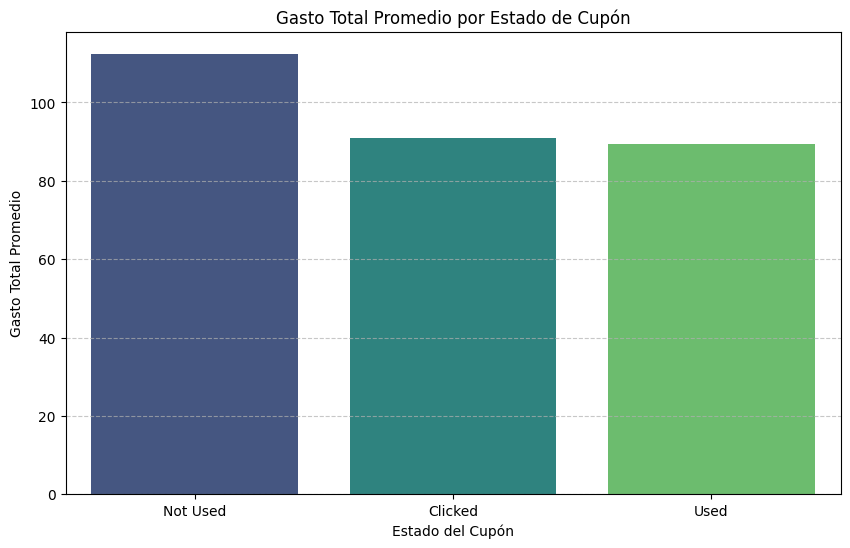

In [35]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x='Coupon_Status', y='Total_Con_Impuestos', data=gasto_por_cupon, palette='viridis')
plt.title('Gasto Total Promedio por Estado de Cupón')
plt.xlabel('Estado del Cupón')
plt.ylabel('Gasto Total Promedio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Por lo tanto, con ésta consulta pudimos obtener de que en realidad las personas que tienen un gasto mayor son las que no ocupan cupones. Por lo cual, quizá las personas no puedan ver como utilizar los cupones, así que sería bueno que en la pagina se de más promoción a los cupones, para que los productos sean más atractivos al cliente.

Ahora, conectemos el dataset creado anteriormente de gasto total con el de customers para ver como se comporta el gasto total de los clientes por región y por género. Primero hagamos el merge.

In [36]:
gasto_customers = pd.merge(
    total_tax,
    customers,
    on="CustomerID",
    how="left"
)
gasto_customers

,CustomerID,Quantity,Product_Category,Avg_Price,Delivery_Charges,Coupon_Status,Discount_pct,Gasto_Total,GST,Total_Con_Impuestos,Gender,Location,Tenure_Months
0,17850,1,Nest-USA,153.71,6.50,Used,10.0,144.839,0.10,159.32290,M,Chicago,12
1,17850,1,Nest-USA,153.71,6.50,Used,10.0,144.839,0.10,159.32290,M,Chicago,12
2,17850,1,Office,2.05,6.50,Used,10.0,8.345,0.10,9.17950,M,Chicago,12
3,17850,5,Apparel,17.53,6.50,Not Used,10.0,94.150,0.18,111.09700,M,Chicago,12
4,17850,1,Bags,16.50,6.50,Used,10.0,21.350,0.18,25.19300,M,Chicago,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
52919,14410,1,Nest-USA,121.30,6.50,Clicked,30.0,91.410,0.10,100.55100,F,New York,45
52920,14410,1,Apparel,48.92,6.50,Used,30.0,40.744,0.18,48.07792,F,New York,45
52921,14410,1,Nest-USA,151.88,6.50,Used,30.0,112.816,0.10,124.09760,F,New York,45
52922,14600,5,Nest-USA,80.52,6.50,Clicked,30.0,288.320,0.10,317.15200,F,California,7


Ahora, primero hagamos la comparación de gasto total por locación.

In [37]:
gasto_por_zona = gasto_customers.groupby('Location')['Total_Con_Impuestos'].mean().reset_index()
gasto_por_zona = gasto_por_zona.sort_values(by='Total_Con_Impuestos', ascending=False)

print("Gasto Total Promedio por Locación:")
display(gasto_por_zona)

Gasto Total Promedio por Locación:


,Location,Total_Con_Impuestos
4,Washington DC,99.123980
2,New Jersey,95.363511
0,California,94.797227
1,Chicago,93.713603
3,New York,89.801725


/tmp/ipykernel_3392/1245859324.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Location', y='Total_Con_Impuestos', data=gasto_por_zona, palette='viridis')


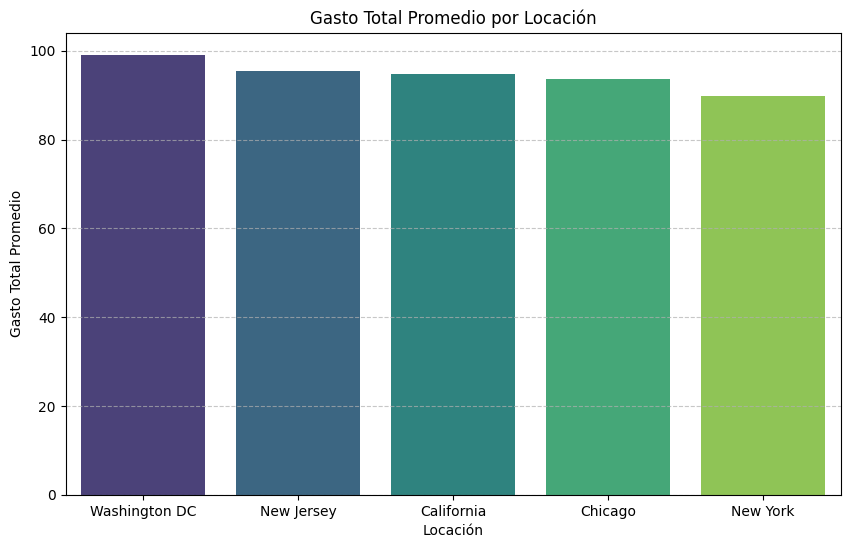

In [38]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x='Location', y='Total_Con_Impuestos', data=gasto_por_zona, palette='viridis')
plt.title('Gasto Total Promedio por Locación')
plt.xlabel('Locación')
plt.ylabel('Gasto Total Promedio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Con esta información en realidad podemos ver que dentro de las ventas por zona todo está equilibrado, por lo que no hay que porponer campañas publicitarias por alguna zona en específico para incrementar nuestras ventas.

Ahora hagamos el análisis por género.

In [39]:
gasto_por_genero = gasto_customers.groupby('Gender')['Total_Con_Impuestos'].mean().reset_index()
gasto_por_genero = gasto_por_genero.sort_values(by='Total_Con_Impuestos', ascending=False)

print("Gasto Total Promedio por Genero:")
display(gasto_por_genero)

Gasto Total Promedio por Genero:


,Gender,Total_Con_Impuestos
1,M,93.788231
0,F,93.547041


/tmp/ipykernel_3392/4255997194.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Gender', y='Total_Con_Impuestos', data=gasto_por_genero, palette='viridis')


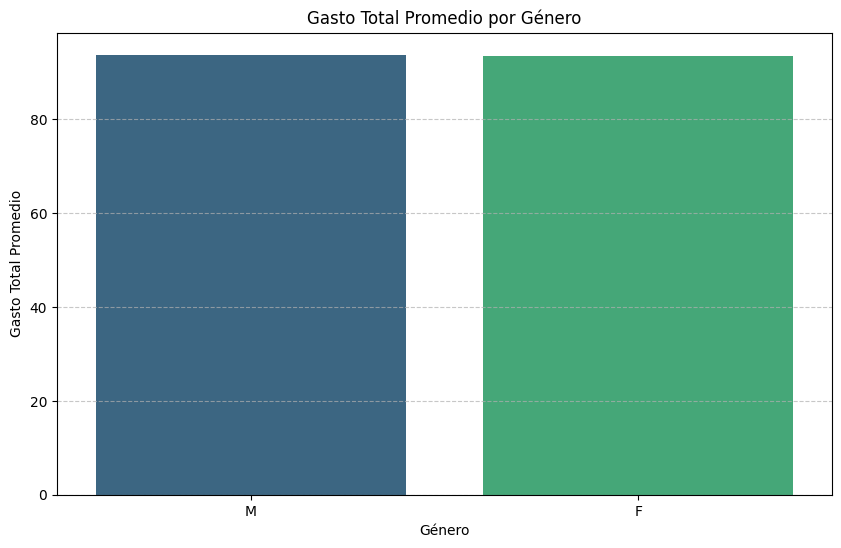

In [40]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.barplot(x='Gender', y='Total_Con_Impuestos', data=gasto_por_genero, palette='viridis')
plt.title('Gasto Total Promedio por Género')
plt.xlabel('Género')
plt.ylabel('Gasto Total Promedio')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Igualmente, podemos ver que por género igualmente se encuentran niveladas.

Ahora, algo importante que se debe de considerar en nuestros gastos es cuánto gastamos en campañas publicitarias y en impuestos, así que hagamos eso.

In [41]:
gasto_por_campaña_offline = marketing['Offline_Spend'].sum()
gasto_por_campaña_online = marketing['Online_Spend'].sum()

/tmp/ipykernel_3392/1108282542.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo de Gasto', y='Gasto Total', data=gasto_campaña, palette={'Offline': 'coral', 'Online': 'lightseagreen'})


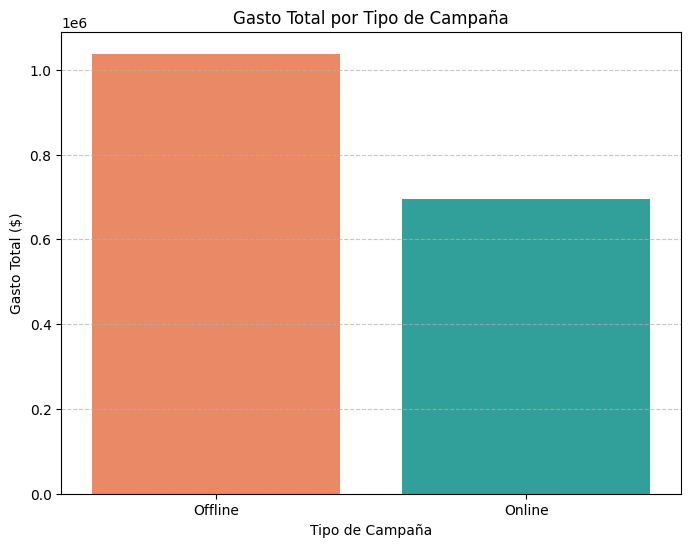

In [42]:
gasto_campaña = pd.DataFrame({
    'Tipo de Gasto': ['Offline', 'Online'],
    'Gasto Total': [gasto_por_campaña_offline, gasto_por_campaña_online]
})
plt.figure(figsize=(8, 6))
sns.barplot(x='Tipo de Gasto', y='Gasto Total', data=gasto_campaña, palette={'Offline': 'coral', 'Online': 'lightseagreen'})
plt.title('Gasto Total por Tipo de Campaña')
plt.xlabel('Tipo de Campaña')
plt.ylabel('Gasto Total ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Por lo tanto, como en general el tipo de campaña en el que más se invierte es en campaña offline, debemos de reubicar esta distribución de campañas, debido a que puede ser de que no estemos llegando a todo el público con ponerle más peso a la campaña online. Debemos de hacer una recopilación de datos por edad para la tabla de customers y, si es que nuestros clientes son generalmente más grandes (de 40 años en adelante por ejemplo), las campañas podrían mantenerse siendo offline. SIn embargo, si nuestros clientes son variados podemos dar más peso a publicidad online para que un público más joven también pueda ver la atractiva oportunidad de comprar en nuestra página.